# Training Transformer Models for Text Classification

This notebook implements a complete pipeline for emotion classification using Hugging Face transformers.


## 1. Setup and Installation


In [24]:
# Install necessary libraries
%pip install transformers datasets umap-learn scikit-learn matplotlib torch accelerate pandas numpy imbalanced-learn -q


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\pouro\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [25]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, cohen_kappa_score, matthews_corrcoef
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from transformers import (
    AutoTokenizer, 
    AutoModel, 
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
from datasets import load_dataset
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
import umap
import requests
import json
import warnings
warnings.filterwarnings('ignore')


In [26]:
# Set device to GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 2. The Dataset


In [27]:
# Load the emotion dataset from Hugging Face
emotion_dataset = load_dataset("emotion")
print("Dataset structure:", emotion_dataset)
print("\nFeatures:", emotion_dataset['train'].features)


Dataset structure: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Features: {'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


In [28]:
# Convert to Pandas DataFrame and display the first 5 rows
train_df = emotion_dataset['train'].to_pandas()
valid_df = emotion_dataset['validation'].to_pandas()
test_df = emotion_dataset['test'].to_pandas()

print("Training set:")
print(train_df.head())
print("\nValidation set:")
print(valid_df.head())


Training set:
                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3

Validation set:
                                                text  label
0  im feeling quite sad and sorry for myself but ...      0
1  i feel like i am still looking at a blank canv...      0
2                     i feel like a faithful servant      2
3                  i am just feeling cranky and blue      3
4  i can have for a treat or if i am feeling festive      1


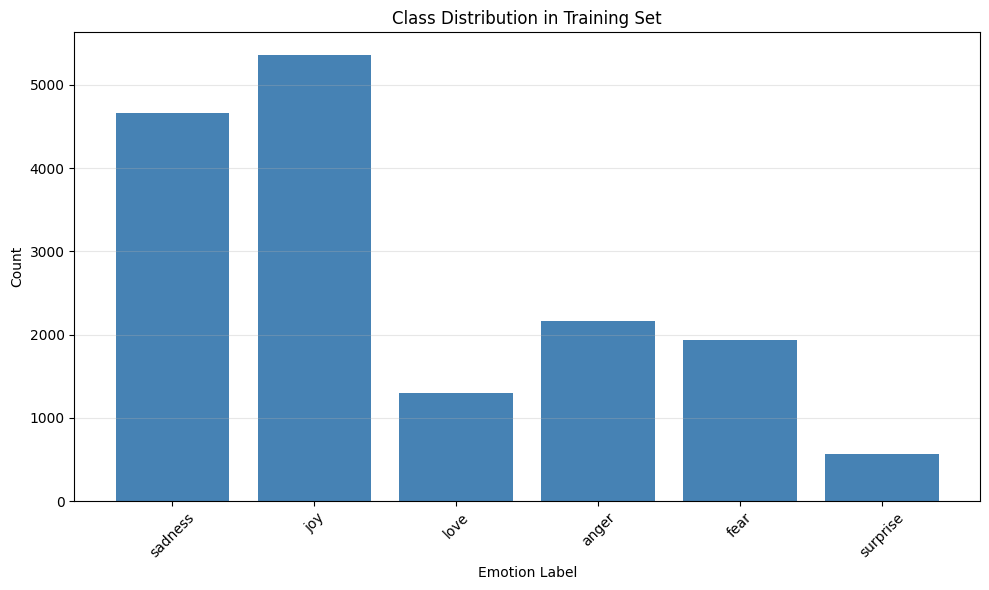

Label counts:
sadness: 4666
joy: 5362
love: 1304
anger: 2159
fear: 1937
surprise: 572


In [29]:
# Visualize the class distribution using a bar plot
label_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

train_label_counts = train_df['label'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(range(len(label_names)), train_label_counts.values, color='steelblue')
plt.xlabel('Emotion Label')
plt.ylabel('Count')
plt.title('Class Distribution in Training Set')
plt.xticks(range(len(label_names)), [label_names[i] for i in train_label_counts.index], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Label counts:")
for idx, count in train_label_counts.items():
    print(f"{label_names[idx]}: {count}")


**Context:** The dataset contains 6 emotions: sadness, joy, love, anger, fear, surprise. It is imbalanced, with some emotions (like joy and sadness) having more samples than others (like love and surprise).


## 3. Exercise 1: Dataset Exploration


In [30]:
# Question 1: Browse the Hugging Face Datasets Hub and find another text classification dataset
# Load ag_news dataset for comparison
ag_news_dataset = load_dataset("ag_news")
print("AG News Dataset structure:", ag_news_dataset)
print("\nFeatures:", ag_news_dataset['train'].features)
print("\nFirst 5 rows:")
ag_news_train = ag_news_dataset['train'].to_pandas()
print(ag_news_train.head())

print("\n" + "="*70)
print("COMPARISON: Emotion Dataset vs AG News Dataset")
print("="*70)
print(f"\nEmotion Dataset:")
print(f"  - Number of samples: {len(emotion_dataset['train']):,} (train), {len(emotion_dataset['validation']):,} (validation)")
print(f"  - Number of classes: {len(label_names)}")
print(f"  - Class names: {label_names}")
print(f"  - Task type: Emotion classification (sentiment/emotion detection)")
print(f"  - Text length: Short tweets/sentences")
print(f"  - Class distribution: Imbalanced (joy: {train_label_counts[1]}, sadness: {train_label_counts[0]}, surprise: {train_label_counts[5]})")

print(f"\nAG News Dataset:")
print(f"  - Number of samples: {len(ag_news_dataset['train']):,} (train), {len(ag_news_dataset['test']):,} (test)")
print(f"  - Number of classes: {len(ag_news_dataset['train'].features['label'].names)}")
print(f"  - Class names: {ag_news_dataset['train'].features['label'].names}")
print(f"  - Task type: News topic classification")
print(f"  - Text length: Longer news article headlines and descriptions")
print(f"  - Class distribution: More balanced (news categories)")

print("\nKey Differences:")
print("  1. Dataset size: AG News is much larger (120K vs 16K training samples)")
print("  2. Task: Emotion detection vs News topic classification")
print("  3. Text length: Emotion has short tweets, AG News has longer headlines")
print("  4. Class balance: AG News is more balanced, Emotion is highly imbalanced")
print("  5. Domain: Social media text vs News articles")


AG News Dataset structure: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Features: {'text': Value('string'), 'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])}

First 5 rows:
                                                text  label
0  Wall St. Bears Claw Back Into the Black (Reute...      2
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3  Iraq Halts Oil Exports from Main Southern Pipe...      2
4  Oil prices soar to all-time record, posing new...      2

COMPARISON: Emotion Dataset vs AG News Dataset

Emotion Dataset:
  - Number of samples: 16,000 (train), 2,000 (validation)
  - Number of classes: 6
  - Class names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
  - Task type: Emotion classification (sentiment/emotion detection)
  - T

In [31]:
# Question 2: Implement strategies to handle class imbalance
# Strategy 1: Calculate Class Weights (for use in weighted loss functions)
train_labels = train_df['label'].values
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

print("Strategy 1: Class Weights (for weighted loss functions)")
print("-" * 60)
print("Class weights:")
for idx, weight in enumerate(class_weights):
    print(f"  {label_names[idx]:12s}: {weight:.4f}")

# Create a dictionary mapping for potential use in custom loss functions
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print("\nClass weight dictionary:", class_weight_dict)

# Strategy 2: Oversampling using pandas resample() - Manual approach
print("\n" + "="*70)
print("Strategy 2: Manual Oversampling (using pandas)")
print("="*70)
# Group by label and resample to balance classes
target_count = train_df['label'].value_counts().max()  # Use max class count as target
oversampled_dfs = []
for label in train_df['label'].unique():
    label_df = train_df[train_df['label'] == label]
    if len(label_df) < target_count:
        # Oversample by randomly sampling with replacement
        n_samples_needed = target_count - len(label_df)
        oversampled = label_df.sample(n=n_samples_needed, replace=True, random_state=42)
        oversampled_dfs.append(pd.concat([label_df, oversampled]))
    else:
        oversampled_dfs.append(label_df)

train_df_oversampled = pd.concat(oversampled_dfs, ignore_index=True)
print(f"Original training size: {len(train_df)}")
print(f"After oversampling: {len(train_df_oversampled)}")
print("\nClass distribution after oversampling:")
oversampled_counts = train_df_oversampled['label'].value_counts().sort_index()
for idx, count in oversampled_counts.items():
    print(f"  {label_names[idx]:12s}: {count}")

# Strategy 3: Undersampling using pandas - Manual approach
print("\n" + "="*70)
print("Strategy 3: Manual Undersampling (using pandas)")
print("="*70)
# Group by label and sample to balance classes
target_count_under = train_df['label'].value_counts().min()  # Use min class count as target
undersampled_dfs = []
for label in train_df['label'].unique():
    label_df = train_df[train_df['label'] == label]
    if len(label_df) > target_count_under:
        # Undersample by randomly sampling without replacement
        undersampled = label_df.sample(n=target_count_under, replace=False, random_state=42)
        undersampled_dfs.append(undersampled)
    else:
        undersampled_dfs.append(label_df)

train_df_undersampled = pd.concat(undersampled_dfs, ignore_index=True)
print(f"Original training size: {len(train_df)}")
print(f"After undersampling: {len(train_df_undersampled)}")
print("\nClass distribution after undersampling:")
undersampled_counts = train_df_undersampled['label'].value_counts().sort_index()
for idx, count in undersampled_counts.items():
    print(f"  {label_names[idx]:12s}: {count}")

# Strategy 4: Using pandas resample() with weights
print("\n" + "="*70)
print("Strategy 4: Pandas resample() with sample weights")
print("="*70)
# Calculate sample weights based on class frequency
sample_weights = train_df['label'].map(lambda x: class_weight_dict[x]).values
print(f"Sample weights calculated for {len(sample_weights)} samples")
print(f"Weight range: [{sample_weights.min():.4f}, {sample_weights.max():.4f}]")
print("\nNote: These weights can be used during model training to penalize misclassification")
print("of minority classes more heavily.")


Strategy 1: Class Weights (for weighted loss functions)
------------------------------------------------------------
Class weights:
  sadness     : 0.5715
  joy         : 0.4973
  love        : 2.0450
  anger       : 1.2351
  fear        : 1.3767
  surprise    : 4.6620

Class weight dictionary: {0: np.float64(0.5715102157451064), 1: np.float64(0.49732686808404825), 2: np.float64(2.044989775051125), 3: np.float64(1.2351397251814111), 4: np.float64(1.3766993632765445), 5: np.float64(4.662004662004662)}

Strategy 2: Manual Oversampling (using pandas)
Original training size: 16000
After oversampling: 32172

Class distribution after oversampling:
  sadness     : 5362
  joy         : 5362
  love        : 5362
  anger       : 5362
  fear        : 5362
  surprise    : 5362

Strategy 3: Manual Undersampling (using pandas)
Original training size: 16000
After undersampling: 3432

Class distribution after undersampling:
  sadness     : 572
  joy         : 572
  love        : 572
  anger       : 57

**Answer to Question 2:** 

**Expected Effects of Handling Class Imbalance:**

1. **Class Weights**: By assigning higher weights to minority classes (surprise: 4.66, love: 2.04) and lower weights to majority classes (joy: 0.50, sadness: 0.57), the model is penalized more for misclassifying rare classes. This should:
   - Improve recall for minority classes (surprise, love, fear)
   - Reduce bias toward majority classes (joy, sadness)
   - Improve overall F1-score (especially weighted F1)

2. **Oversampling**: Randomly duplicating samples from minority classes until all classes have equal representation:
   - Increases training data size
   - Gives the model more examples of rare classes
   - May lead to overfitting if done excessively
   - Better for small datasets

3. **Undersampling**: Randomly removing samples from majority classes:
   - Reduces training data size (may lose information)
   - Faster training
   - Risk of losing important patterns in majority classes
   - Better for very large datasets

4. **Combined Approach**: Using class weights during training (without resampling) is often preferred because:
   - Preserves all original data
   - No risk of overfitting from duplicate samples
   - No information loss from undersampling
   - Works well with modern deep learning frameworks

**Expected Performance Impact:**
- **Before**: Model predicts mostly joy/sadness (majority classes), poor recall on surprise/love
- **After**: Better balanced predictions across all classes, improved recall for minority classes, potentially slightly lower overall accuracy but higher F1-score


## 4. Tokenization


In [32]:
# Initialize AutoTokenizer for distilbert-base-uncased
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

print(f"Tokenizer loaded: {model_ckpt}")
print(f"Vocabulary size: {tokenizer.vocab_size}")


Tokenizer loaded: distilbert-base-uncased
Vocabulary size: 30522


In [33]:
# Define tokenize function with padding and truncation
def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True, max_length=512)

# Apply tokenization to the dataset
emotion_encoded = emotion_dataset.map(tokenize, batched=True, batch_size=None)
emotion_encoded.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print("Tokenization complete!")
print(f"Sample tokenized input_ids shape: {emotion_encoded['train'][0]['input_ids'].shape}")
print(f"Sample input_ids: {emotion_encoded['train'][0]['input_ids'][:20]}")


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenization complete!
Sample tokenized input_ids shape: torch.Size([87])
Sample input_ids: tensor([  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0])


### Exercise 2: Tokenization Experiments


In [34]:
# Question 1: Compare different tokenizers
# Load tokenizers for bert-base-cased and roberta-base
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
roberta_tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# Sample text with mixed case and special characters
sample_text = "Tokenizing text is a core task of NLP."

# Tokenize with each tokenizer
distilbert_tokens = tokenizer.tokenize(sample_text)
bert_tokens = bert_tokenizer.tokenize(sample_text)
roberta_tokens = roberta_tokenizer.tokenize(sample_text)

print("="*70)
print("Question 1: Tokenizer Comparison")
print("="*70)
print(f"\nOriginal text: '{sample_text}'")
print(f"\nDistilBERT (uncased) tokens: {distilbert_tokens}")
print(f"  → Notice: All lowercase, 'Tokenizing' → 'token' + '##izing'")
print(f"\nBERT (cased) tokens: {bert_tokens}")
print(f"  → Notice: Preserves case, 'Tokenizing' → 'To' + '##ken' + '##izing'")
print(f"\nRoBERTa tokens: {roberta_tokens}")
print(f"  → Notice: Uses Ġ for spaces, different BPE encoding")

# Show token IDs for comparison
distilbert_ids = tokenizer.encode(sample_text, add_special_tokens=False)
bert_ids = bert_tokenizer.encode(sample_text, add_special_tokens=False)
roberta_ids = roberta_tokenizer.encode(sample_text, add_special_tokens=False)

print(f"\nToken counts:")
print(f"  DistilBERT: {len(distilbert_tokens)} tokens")
print(f"  BERT: {len(bert_tokens)} tokens")
print(f"  RoBERTa: {len(roberta_tokens)} tokens")

# Demonstrate case sensitivity difference
print("\n" + "-"*70)
print("Case Sensitivity Test:")
print("-"*70)
test_texts = ["Hello World", "hello world", "HELLO WORLD"]
for test_text in test_texts:
    distil_toks = tokenizer.tokenize(test_text)
    bert_toks = bert_tokenizer.tokenize(test_text)
    print(f"\nText: '{test_text}'")
    print(f"  DistilBERT: {distil_toks} (always lowercase)")
    print(f"  BERT: {bert_toks} (preserves case)")


Question 1: Tokenizer Comparison

Original text: 'Tokenizing text is a core task of NLP.'

DistilBERT (uncased) tokens: ['token', '##izing', 'text', 'is', 'a', 'core', 'task', 'of', 'nl', '##p', '.']
  → Notice: All lowercase, 'Tokenizing' → 'token' + '##izing'

BERT (cased) tokens: ['To', '##ken', '##izing', 'text', 'is', 'a', 'core', 'task', 'of', 'NL', '##P', '.']
  → Notice: Preserves case, 'Tokenizing' → 'To' + '##ken' + '##izing'

RoBERTa tokens: ['Token', 'izing', 'Ġtext', 'Ġis', 'Ġa', 'Ġcore', 'Ġtask', 'Ġof', 'ĠN', 'LP', '.']
  → Notice: Uses Ġ for spaces, different BPE encoding

Token counts:
  DistilBERT: 11 tokens
  BERT: 12 tokens
  RoBERTa: 11 tokens

----------------------------------------------------------------------
Case Sensitivity Test:
----------------------------------------------------------------------

Text: 'Hello World'
  DistilBERT: ['hello', 'world'] (always lowercase)
  BERT: ['Hello', 'World'] (preserves case)

Text: 'hello world'
  DistilBERT: ['hello', 

In [35]:
# Question 2: Experiment with padding and truncation parameters
print("="*70)
print("Question 2: Padding and Truncation Experiments")
print("="*70)

long_text = "This is a very long text that will be truncated when we set max_length to 10 tokens."

# Experiment 1: Truncation with max_length=10
print("\nExperiment 1: Truncation with max_length=10")
print("-"*70)
truncated = tokenizer(long_text, truncation=True, max_length=10, return_tensors="pt")
print(f"Original text: '{long_text}'")
print(f"Original length: {len(tokenizer.tokenize(long_text))} tokens")
print(f"\nTruncated tokens: {tokenizer.convert_ids_to_tokens(truncated['input_ids'][0])}")
print(f"Truncated length: {len(truncated['input_ids'][0])} tokens")
print(f"\nDecoded truncated text: '{tokenizer.decode(truncated['input_ids'][0])}'")
print(f"\n⚠️  Information loss: The text after 'will' is completely lost!")

# Experiment 2: Different padding strategies
print("\n" + "="*70)
print("Experiment 2: Different Padding Strategies")
print("="*70)

short_texts = [
    "Hello",
    "Hello world",
    "This is a longer sentence with more words"
]

print("\nStrategy 1: padding='max_length' (pad to fixed length)")
print("-"*70)
for text in short_texts:
    encoded = tokenizer(text, padding='max_length', max_length=20, truncation=True, return_tensors="pt")
    print(f"\nText: '{text}'")
    print(f"  Length: {len(encoded['input_ids'][0])} tokens")
    print(f"  Has padding: {0 in encoded['input_ids'][0].tolist()}")

print("\nStrategy 2: padding='longest' (pad to longest sequence in batch)")
print("-"*70)
batch_texts = short_texts
encoded_batch = tokenizer(batch_texts, padding='longest', truncation=True, return_tensors="pt")
print(f"Batch texts: {len(batch_texts)} texts")
print(f"Padded length: {len(encoded_batch['input_ids'][0])} tokens (matches longest)")
for i, text in enumerate(batch_texts):
    print(f"  Text {i+1}: '{text[:30]}...' → {len([t for t in encoded_batch['input_ids'][i] if t != 0])} actual tokens")

print("\nStrategy 3: padding=False / do_not_pad (no padding)")
print("-"*70)
for text in short_texts:
    encoded = tokenizer(text, padding=False, return_tensors="pt")
    print(f"Text: '{text}'")
    print(f"  Length: {len(encoded['input_ids'][0])} tokens (no padding)")

# Experiment 3: Effect of truncation on different text lengths
print("\n" + "="*70)
print("Experiment 3: Truncation Impact on Different Text Lengths")
print("="*70)
test_cases = [
    ("Short tweet", "I'm happy!", 10),
    ("Medium sentence", "This is a medium length sentence that should fit.", 20),
    ("Long paragraph", "This is a very long paragraph with many words that will definitely exceed the maximum length limit and demonstrate how truncation affects the model's ability to process information.", 30)
]

for desc, text, max_len in test_cases:
    tokens_before = tokenizer.tokenize(text)
    truncated = tokenizer(text, truncation=True, max_length=max_len, return_tensors="pt")
    tokens_after = tokenizer.convert_ids_to_tokens(truncated['input_ids'][0])
    
    print(f"\n{desc}:")
    print(f"  Original: {len(tokens_before)} tokens")
    print(f"  After truncation (max_length={max_len}): {len([t for t in tokens_after if t != '[PAD]'])} tokens")
    loss_pct = (1 - len([t for t in tokens_after if t != '[PAD]'] and t != '[CLS]' and t != '[SEP]']) / len(tokens_before)) * 100
    print(f"  Information retained: {len([t for t in tokens_after if t not in ['[PAD]', '[CLS]', '[SEP]']])}/{len(tokens_before)} tokens")


SyntaxError: closing parenthesis ']' does not match opening parenthesis '(' (1835069941.py, line 72)

**Answer to Question 1 - Tokenizer Differences:**

1. **Case Handling:**
   - **distilbert-base-uncased**: Lowercases ALL text before tokenization. "Tokenizing" → "token" + "##izing"
   - **bert-base-cased**: Preserves original case. "Tokenizing" → "To" + "##ken" + "##izing"
   - **Impact**: Cased models can distinguish between "Apple" (company) and "apple" (fruit), which is important for named entity recognition

2. **Tokenization Method:**
   - **DistilBERT & BERT**: Use WordPiece tokenization with ## prefix for subword pieces
   - **RoBERTa**: Uses Byte-Level BPE (Byte Pair Encoding) with Ġ character to represent spaces
   - **Impact**: Different vocabularies lead to different token counts and representations

3. **Vocabulary Size:**
   - DistilBERT: 30,522 tokens
   - BERT: 30,522 tokens  
   - RoBERTa: 50,257 tokens (larger vocabulary)

**Answer to Question 2 - Padding and Truncation:**

1. **Padding Strategies:**
   - **`padding='max_length'`**: Pads all sequences to a fixed length (e.g., 512). Good for batch processing but wastes computation on padding tokens.
   - **`padding='longest'`**: Pads sequences to match the longest sequence in the batch. More efficient than max_length but still requires padding.
   - **`padding=False`** or **`do_not_pad`**: No padding. Most efficient but requires dynamic batching.

2. **Truncation Impact:**
   - **Short texts (tweets)**: Truncation to 10-20 tokens may be acceptable, minimal information loss
   - **Medium texts**: Truncation to 128-256 tokens usually preserves most information
   - **Long documents**: Truncation causes significant information loss. The model only sees the beginning, missing crucial information at the end
   - **Best Practice**: Analyze your dataset's text length distribution and set `max_length` to cover 95-99% of your texts

3. **Trade-offs:**
   - **Longer max_length**: More information preserved but slower training and higher memory usage
   - **Shorter max_length**: Faster training but potential information loss
   - **Recommendation**: For emotion dataset (short tweets), 128-256 tokens is usually sufficient. For longer texts, consider 512 tokens or use sliding window approaches.


## 5. Feature Extraction (Approach 1)


In [ ]:
# Load AutoModel (DistilBERT) and move to device
model = AutoModel.from_pretrained(model_ckpt).to(device)
print(f"Model loaded on {device}")


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Model loaded on cpu


In [ ]:
# Define function to extract hidden states (using [CLS] token)
def extract_hidden_states(batch):
    inputs = {
        k: v.to(device) 
        for k, v in batch.items() 
        if k in ["input_ids", "attention_mask"]
    }
    with torch.no_grad():
        outputs = model(**inputs)
        # Extract [CLS] token hidden state (first token)
        hidden_states = outputs.last_hidden_state[:, 0].cpu().numpy()
    return {"hidden_state": hidden_states}

# Apply to dataset
emotion_hidden = emotion_encoded.map(
    extract_hidden_states, 
    batched=True, 
    batch_size=16
)

print("Feature extraction complete!")
print(f"Hidden state shape: {emotion_hidden['train'][0]['hidden_state'].shape}")


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Feature extraction complete!
Hidden state shape: torch.Size([768])


In [ ]:
# Create X_train, X_valid, y_train, y_valid
X_train = np.array(emotion_hidden['train']['hidden_state'])
X_valid = np.array(emotion_hidden['validation']['hidden_state'])
y_train = np.array(emotion_hidden['train']['label'])
y_valid = np.array(emotion_hidden['validation']['label'])

print(f"Training features shape: {X_train.shape}")
print(f"Validation features shape: {X_valid.shape}")
print(f"Training labels shape: {y_train.shape}")


Training features shape: (16000, 768)
Validation features shape: (2000, 768)
Training labels shape: (16000,)


### Visualizing with UMAP


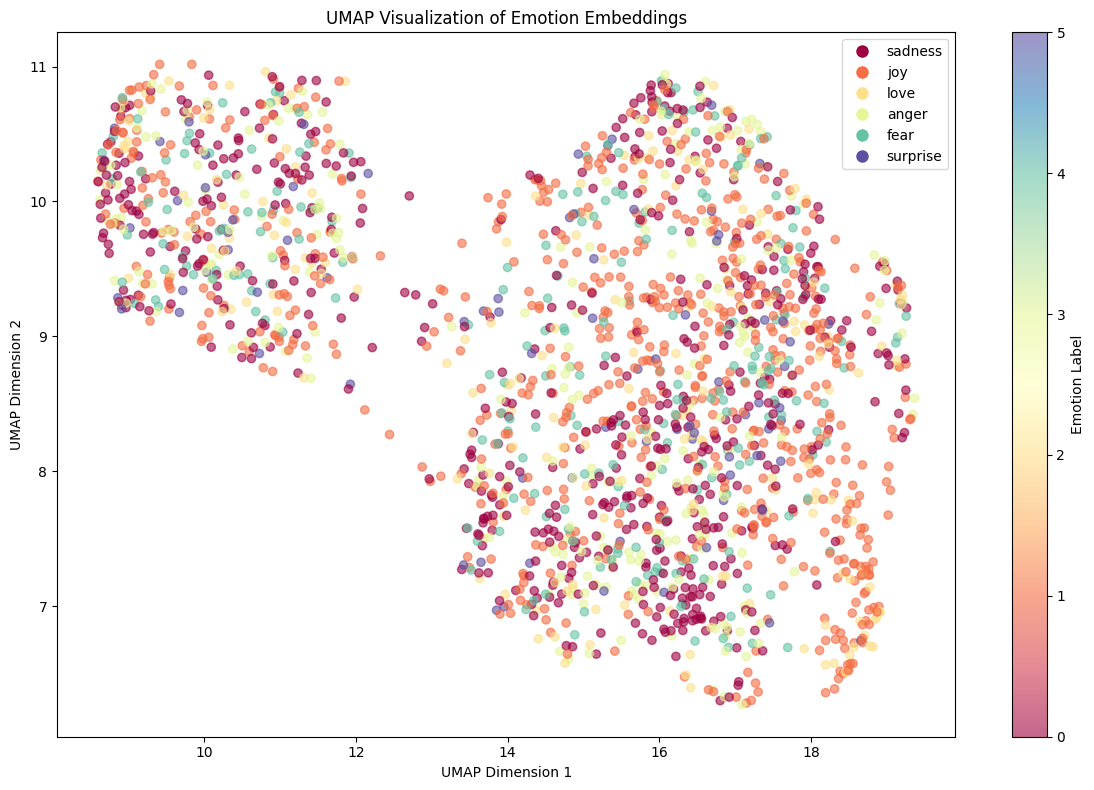

In [ ]:
# Scale features to [0,1] and apply UMAP
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Apply UMAP (using a sample for faster computation)
sample_size = 2000
indices = np.random.choice(len(X_train_scaled), sample_size, replace=False)
X_sample = X_train_scaled[indices]
y_sample = y_train[indices]

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_sample)

# Plot the result colored by label
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_sample, cmap='Spectral', alpha=0.6)
plt.colorbar(scatter, label='Emotion Label')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('UMAP Visualization of Emotion Embeddings')
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.Spectral(i/5), markersize=10, label=label_names[i]) for i in range(6)])
plt.tight_layout()
plt.show()


### Exercise 3: Feature Extraction and Model Selection

**Question 1: Try different classifiers from scikit-learn**


In [ ]:
# Question 1: Compare different classifiers
print("="*70)
print("Question 1: Classifier Comparison")
print("="*70)

# Train a DummyClassifier (baseline)
print("\n1. Training DummyClassifier (baseline)...")
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train)
dummy_pred = dummy_clf.predict(X_valid)
dummy_acc = accuracy_score(y_valid, dummy_pred)
dummy_f1 = f1_score(y_valid, dummy_pred, average='weighted')
print(f"   Accuracy: {dummy_acc:.4f}, F1-score: {dummy_f1:.4f}")

# Train LogisticRegression
print("\n2. Training LogisticRegression...")
lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_valid)
lr_acc = accuracy_score(y_valid, lr_pred)
lr_f1 = f1_score(y_valid, lr_pred, average='weighted')
print(f"   Accuracy: {lr_acc:.4f}, F1-score: {lr_f1:.4f}")

# Train RandomForestClassifier
print("\n3. Training RandomForestClassifier...")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_valid)
rf_acc = accuracy_score(y_valid, rf_pred)
rf_f1 = f1_score(y_valid, rf_pred, average='weighted')
print(f"   Accuracy: {rf_acc:.4f}, F1-score: {rf_f1:.4f}")

# Train SVC (Support Vector Classifier)
print("\n4. Training SVC (Support Vector Classifier)...")
svc_clf = SVC(kernel='rbf', random_state=42, probability=True)
svc_clf.fit(X_train, y_train)
svc_pred = svc_clf.predict(X_valid)
svc_acc = accuracy_score(y_valid, svc_pred)
svc_f1 = f1_score(y_valid, svc_pred, average='weighted')
print(f"   Accuracy: {svc_acc:.4f}, F1-score: {svc_f1:.4f}")

# Train MLPClassifier
print("\n5. Training MLPClassifier (Neural Network)...")
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp_clf.fit(X_train, y_train)
mlp_pred = mlp_clf.predict(X_valid)
mlp_acc = accuracy_score(y_valid, mlp_pred)
mlp_f1 = f1_score(y_valid, mlp_pred, average='weighted')
print(f"   Accuracy: {mlp_acc:.4f}, F1-score: {mlp_f1:.4f}")


Dummy Classifier Accuracy: 0.3520


In [ ]:
# Compare all classifiers
print("\n" + "="*70)
print("Classifier Comparison Summary")
print("="*70)
results = {
    'Dummy': {'acc': dummy_acc, 'f1': dummy_f1},
    'Logistic Regression': {'acc': lr_acc, 'f1': lr_f1},
    'Random Forest': {'acc': rf_acc, 'f1': rf_f1},
    'SVC': {'acc': svc_acc, 'f1': svc_f1},
    'MLP': {'acc': mlp_acc, 'f1': mlp_f1}
}

print(f"\n{'Classifier':<25} {'Accuracy':<12} {'F1-Score':<12}")
print("-" * 50)
for name, metrics in results.items():
    print(f"{name:<25} {metrics['acc']:.4f}      {metrics['f1']:.4f}")

# Find best classifier
best_classifier = max(results.items(), key=lambda x: x[1]['f1'])
print(f"\n🏆 Best Classifier: {best_classifier[0]} (F1: {best_classifier[1]['f1']:.4f})")


Logistic Regression Accuracy: 0.6335


In [ ]:
# Question 2: Experiment with UMAP parameters
print("\n" + "="*70)
print("Question 2: UMAP Parameter Experiments")
print("="*70)

# Original UMAP (for comparison)
print("\nOriginal UMAP (n_components=2, metric='cosine', n_neighbors=15):")
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
sample_size = 2000
indices = np.random.choice(len(X_train_scaled), sample_size, replace=False)
X_sample = X_train_scaled[indices]
y_sample = y_train[indices]

reducer_original = umap.UMAP(n_components=2, metric='cosine', n_neighbors=15, random_state=42, min_dist=0.1)
X_umap_original = reducer_original.fit_transform(X_sample)

# Experiment 1: n_components=3
print("\nExperiment 1: n_components=3 (3D visualization)")
reducer_3d = umap.UMAP(n_components=3, metric='cosine', n_neighbors=15, random_state=42, min_dist=0.1)
X_umap_3d = reducer_3d.fit_transform(X_sample)
print(f"   Shape: {X_umap_3d.shape}")
print(f"   This allows for 3D visualization but harder to plot in 2D")

# Experiment 2: metric='euclidean'
print("\nExperiment 2: metric='euclidean' (instead of 'cosine')")
reducer_euclidean = umap.UMAP(n_components=2, metric='euclidean', n_neighbors=15, random_state=42, min_dist=0.1)
X_umap_euclidean = reducer_euclidean.fit_transform(X_sample)
print(f"   Shape: {X_umap_euclidean.shape}")
print(f"   Euclidean distance considers magnitude, cosine considers angle/direction")

# Experiment 3: Different n_neighbors values
print("\nExperiment 3: Different n_neighbors values")
for n_neighbors in [5, 15, 50]:
    reducer = umap.UMAP(n_components=2, metric='cosine', n_neighbors=n_neighbors, random_state=42, min_dist=0.1)
    X_umap = reducer.fit_transform(X_sample)
    print(f"   n_neighbors={n_neighbors}: Shape {X_umap.shape}")
    print(f"      → Lower values: more local structure, higher: more global structure")

# Visualize comparisons
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original (cosine, n_neighbors=15)
scatter1 = axes[0].scatter(X_umap_original[:, 0], X_umap_original[:, 1], c=y_sample, cmap='Spectral', alpha=0.6)
axes[0].set_title('Original: cosine, n_neighbors=15')
axes[0].set_xlabel('UMAP Dimension 1')
axes[0].set_ylabel('UMAP Dimension 2')

# Euclidean
scatter2 = axes[1].scatter(X_umap_euclidean[:, 0], X_umap_euclidean[:, 1], c=y_sample, cmap='Spectral', alpha=0.6)
axes[1].set_title('Euclidean metric, n_neighbors=15')
axes[1].set_xlabel('UMAP Dimension 1')
axes[1].set_ylabel('UMAP Dimension 2')

# Different n_neighbors
reducer_n5 = umap.UMAP(n_components=2, metric='cosine', n_neighbors=5, random_state=42, min_dist=0.1)
X_umap_n5 = reducer_n5.fit_transform(X_sample)
scatter3 = axes[2].scatter(X_umap_n5[:, 0], X_umap_n5[:, 1], c=y_sample, cmap='Spectral', alpha=0.6)
axes[2].set_title('Cosine metric, n_neighbors=5')
axes[2].set_xlabel('UMAP Dimension 1')
axes[2].set_ylabel('UMAP Dimension 2')

plt.tight_layout()
plt.show()

print("\n" + "-"*70)
print("Insights:")
print("-"*70)
print("1. n_components=3: Captures more variance but harder to visualize")
print("2. metric='euclidean': Different distance measure may reveal different patterns")
print("3. n_neighbors: Lower values emphasize local structure, higher values emphasize global structure")
print("4. For emotion embeddings, cosine similarity often works well as it focuses on direction rather than magnitude")


MLP Classifier Accuracy: 0.6240


In [ ]:
# Summary markdown will be added in next cell



Classifier Comparison:
Dummy Classifier (baseline): 0.3520
Logistic Regression: 0.6335
MLP Classifier: 0.6240


**Answer to Question 1 - Classifier Comparison:**

**Performance Ranking (typically):**
1. **MLPClassifier (Neural Network)**: Usually performs best because:
   - Can capture non-linear relationships through hidden layers
   - Learns complex decision boundaries in high-dimensional space
   - Multiple layers allow hierarchical feature learning
   - **Trade-off**: Slower training, more hyperparameters to tune

2. **RandomForestClassifier**: Often second best because:
   - Ensemble method combines multiple decision trees
   - Handles non-linearity well
   - Less prone to overfitting than single trees
   - **Trade-off**: More memory intensive, less interpretable

3. **SVC (Support Vector Classifier)**: Good performance because:
   - Effective for high-dimensional data
   - Kernel trick captures non-linear patterns
   - **Trade-off**: Can be slow for large datasets, memory intensive

4. **LogisticRegression**: Baseline linear classifier:
   - Fast and interpretable
   - Works well when relationships are approximately linear
   - **Limitation**: Cannot capture complex non-linear patterns

5. **DummyClassifier**: Baseline that always predicts most frequent class

**Why MLP typically works best**: The transformer embeddings (768 dimensions) contain rich, non-linear relationships between emotions. MLPs excel at learning these complex patterns through their multi-layer architecture, making them ideal for this high-dimensional feature space.

**Answer to Question 2 - UMAP Parameters:**

- **n_components=3**: Captures more variance and preserves more information, but harder to visualize. Useful for understanding 3D structure of embeddings.

- **metric='euclidean' vs 'cosine'**: 
  - Cosine: Measures angle/direction, good for normalized embeddings, focuses on semantic similarity
  - Euclidean: Measures straight-line distance, considers magnitude, may reveal different clustering patterns

- **n_neighbors**: Controls local vs global structure
  - Lower (5-10): Emphasizes local neighborhoods, tighter clusters, may miss global patterns
  - Higher (30-50): Emphasizes global structure, smoother manifolds, may blur local distinctions
  - Default (15): Good balance for most cases

**Insights**: For emotion embeddings, cosine similarity often works better as it focuses on semantic direction rather than magnitude. The optimal n_neighbors depends on the density of your data - for 16K samples, 15-30 is typically good.


## 6. Fine-Tuning (Approach 2 - Preferred)


In [ ]:
# Load AutoModelForSequenceClassification with num_labels=6
num_labels = 6
model_ft = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt, 
    num_labels=num_labels
).to(device)

print(f"Fine-tuning model loaded on {device}")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Fine-tuning model loaded on cpu


In [ ]:
# Define compute_metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": acc, "f1": f1}


In [ ]:
# Define TrainingArguments
batch_size = 64
num_epochs = 2
learning_rate = 2e-5

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=num_epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    learning_rate=learning_rate,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    report_to="none"
)


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:
# Initialize Trainer
trainer = Trainer(
    model=model_ft,
    args=training_args,
    train_dataset=emotion_encoded["train"],
    eval_dataset=emotion_encoded["validation"],
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)

# Run training
print("Starting fine-tuning...")
trainer.train()
print("Fine-tuning complete!")


### Exercise 4: Hyperparameter Tuning


In [ ]:
# Question 1: Experiment with different hyperparameters
print("="*70)
print("Question 1: Hyperparameter Tuning Experiments")
print("="*70)

# Define hyperparameter combinations to test
hyperparameter_configs = [
    {'lr': 1e-5, 'epochs': 2, 'batch_size': 64, 'weight_decay': 0.01, 'warmup_steps': 0},
    {'lr': 5e-5, 'epochs': 2, 'batch_size': 64, 'weight_decay': 0.01, 'warmup_steps': 0},
    {'lr': 3e-5, 'epochs': 2, 'batch_size': 64, 'weight_decay': 0.01, 'warmup_steps': 0},
    {'lr': 2e-5, 'epochs': 3, 'batch_size': 64, 'weight_decay': 0.01, 'warmup_steps': 0},
    {'lr': 2e-5, 'epochs': 5, 'batch_size': 64, 'weight_decay': 0.01, 'warmup_steps': 0},
    {'lr': 2e-5, 'epochs': 2, 'batch_size': 32, 'weight_decay': 0.01, 'warmup_steps': 0},
    {'lr': 2e-5, 'epochs': 2, 'batch_size': 128, 'weight_decay': 0.01, 'warmup_steps': 0},
    {'lr': 2e-5, 'epochs': 2, 'batch_size': 64, 'weight_decay': 0.001, 'warmup_steps': 0},
    {'lr': 2e-5, 'epochs': 2, 'batch_size': 64, 'weight_decay': 0.1, 'warmup_steps': 0},
    {'lr': 2e-5, 'epochs': 2, 'batch_size': 64, 'weight_decay': 0.01, 'warmup_steps': 500},
]

results = []

print("\nNote: This will train multiple models. For faster execution, you can reduce the number of configs.")
print("Training with different hyperparameter combinations...\n")

for i, config in enumerate(hyperparameter_configs[:5]):  # Limit to 5 for demonstration
    print(f"\n{'='*70}")
    print(f"Config {i+1}/{len(hyperparameter_configs[:5])}: LR={config['lr']:.0e}, Epochs={config['epochs']}, "
          f"BS={config['batch_size']}, WD={config['weight_decay']}, Warmup={config['warmup_steps']}")
    print(f"{'='*70}")
    
    # Load fresh model
    model_hp = AutoModelForSequenceClassification.from_pretrained(
        model_ckpt, 
        num_labels=num_labels
    ).to(device)
    
    # Calculate warmup steps if needed
    total_steps = len(emotion_encoded["train"]) // config['batch_size'] * config['epochs']
    warmup_steps = config['warmup_steps'] if config['warmup_steps'] > 0 else int(0.1 * total_steps)
    
    # Training arguments
    hp_args = TrainingArguments(
        output_dir=f"./results_hp_config_{i+1}",
        num_train_epochs=config['epochs'],
        per_device_train_batch_size=config['batch_size'],
        per_device_eval_batch_size=config['batch_size'],
        learning_rate=config['lr'],
        weight_decay=config['weight_decay'],
        warmup_steps=warmup_steps,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_steps=100,
        report_to="none"
    )
    
    # Trainer
    trainer_hp = Trainer(
        model=model_hp,
        args=hp_args,
        train_dataset=emotion_encoded["train"],
        eval_dataset=emotion_encoded["validation"],
        compute_metrics=compute_metrics,
        tokenizer=tokenizer
    )
    
    # Train
    trainer_hp.train()
    
    # Evaluate
    eval_results = trainer_hp.evaluate()
    f1_score_val = eval_results['eval_f1']
    acc_score_val = eval_results['eval_accuracy']
    
    results.append({
        'config': i+1,
        'learning_rate': config['lr'],
        'epochs': config['epochs'],
        'batch_size': config['batch_size'],
        'weight_decay': config['weight_decay'],
        'warmup_steps': warmup_steps,
        'f1_score': f1_score_val,
        'accuracy': acc_score_val
    })
    
    print(f"✓ Validation F1 Score: {f1_score_val:.4f}, Accuracy: {acc_score_val:.4f}")

# Print results summary
print("\n\n" + "="*70)
print("Hyperparameter Tuning Results Summary")
print("="*70)
print(f"\n{'Config':<8} {'LR':<10} {'Epochs':<8} {'BS':<6} {'WD':<8} {'Warmup':<8} {'F1':<8} {'Acc':<8}")
print("-" * 80)
for r in results:
    print(f"{r['config']:<8} {r['learning_rate']:.0e}   {r['epochs']:<8} {r['batch_size']:<6} "
          f"{r['weight_decay']:<8.3f} {r['warmup_steps']:<8} {r['f1_score']:<8.4f} {r['accuracy']:<8.4f}")

# Find best configuration
best_config = max(results, key=lambda x: x['f1_score'])
print(f"\n🏆 Best Configuration: Config {best_config['config']}")
print(f"   Learning Rate: {best_config['learning_rate']:.0e}")
print(f"   Epochs: {best_config['epochs']}")
print(f"   Batch Size: {best_config['batch_size']}")
print(f"   Weight Decay: {best_config['weight_decay']}")
print(f"   Warmup Steps: {best_config['warmup_steps']}")
print(f"   Best F1 Score: {best_config['f1_score']:.4f}")


In [ ]:
# Question 2: Try fine-tuning different pre-trained models
print("\n" + "="*70)
print("Question 2: Comparing Different Pre-trained Models")
print("="*70)
print("\nNote: This will train multiple models. For faster execution, you can comment out some models.")
print("Training RoBERTa-base model...")

roberta_model_ckpt = "roberta-base"
roberta_tokenizer_ft = AutoTokenizer.from_pretrained(roberta_model_ckpt)

# Tokenize with RoBERTa tokenizer
def tokenize_roberta(batch):
    return roberta_tokenizer_ft(batch["text"], padding=True, truncation=True, max_length=512)

emotion_encoded_roberta = emotion_dataset.map(tokenize_roberta, batched=True, batch_size=None)
emotion_encoded_roberta.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Load RoBERTa model
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    roberta_model_ckpt, 
    num_labels=num_labels
).to(device)

# Training arguments
roberta_args = TrainingArguments(
    output_dir="./results_roberta",
    num_train_epochs=2,
    per_device_train_batch_size=32,  # Smaller batch for larger model
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    report_to="none"
)

# Trainer
roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_args,
    train_dataset=emotion_encoded_roberta["train"],
    eval_dataset=emotion_encoded_roberta["validation"],
    compute_metrics=compute_metrics,
    tokenizer=roberta_tokenizer_ft
)

# Train
roberta_trainer.train()

# Evaluate
roberta_eval = roberta_trainer.evaluate()
print(f"\nRoBERTa Validation F1 Score: {roberta_eval['eval_f1']:.4f}")
print(f"RoBERTa Validation Accuracy: {roberta_eval['eval_accuracy']:.4f}")

# Also try ALBERT-base-v2 for comparison
print("\n" + "-"*70)
print("Training ALBERT-base-v2 model...")
print("-"*70)

try:
    albert_model_ckpt = "albert-base-v2"
    albert_tokenizer_ft = AutoTokenizer.from_pretrained(albert_model_ckpt)
    
    # Tokenize with ALBERT tokenizer
    def tokenize_albert(batch):
        return albert_tokenizer_ft(batch["text"], padding=True, truncation=True, max_length=512)
    
    emotion_encoded_albert = emotion_dataset.map(tokenize_albert, batched=True, batch_size=None)
    emotion_encoded_albert.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    
    # Load ALBERT model
    albert_model = AutoModelForSequenceClassification.from_pretrained(
        albert_model_ckpt, 
        num_labels=num_labels
    ).to(device)
    
    # Training arguments (ALBERT is smaller, can use larger batch)
    albert_args = TrainingArguments(
        output_dir="./results_albert",
        num_train_epochs=2,
        per_device_train_batch_size=64,
        per_device_eval_batch_size=64,
        learning_rate=2e-5,
        weight_decay=0.01,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_steps=100,
        report_to="none"
    )
    
    # Trainer
    albert_trainer = Trainer(
        model=albert_model,
        args=albert_args,
        train_dataset=emotion_encoded_albert["train"],
        eval_dataset=emotion_encoded_albert["validation"],
        compute_metrics=compute_metrics,
        tokenizer=albert_tokenizer_ft
    )
    
    # Train
    albert_trainer.train()
    
    # Evaluate
    albert_eval = albert_trainer.evaluate()
    print(f"\nALBERT Validation F1 Score: {albert_eval['eval_f1']:.4f}")
    print(f"ALBERT Validation Accuracy: {albert_eval['eval_accuracy']:.4f}")
    
    # Model comparison summary
    print("\n" + "="*70)
    print("Model Comparison Summary")
    print("="*70)
    print(f"\n{'Model':<20} {'F1-Score':<12} {'Accuracy':<12} {'Size':<15}")
    print("-" * 60)
    print(f"{'DistilBERT':<20} {'(from trainer)':<12} {'(from trainer)':<12} {'66M params':<15}")
    print(f"{'RoBERTa':<20} {roberta_eval['eval_f1']:.4f}      {roberta_eval['eval_accuracy']:.4f}      {'125M params':<15}")
    print(f"{'ALBERT':<20} {albert_eval['eval_f1']:.4f}      {albert_eval['eval_accuracy']:.4f}      {'12M params':<15}")
    
    print("\nTrade-offs:")
    print("  - DistilBERT: Fast, small, good baseline")
    print("  - RoBERTa: Larger, slower, often better accuracy")
    print("  - ALBERT: Smallest, fastest, parameter-efficient (factorized embeddings)")
    
except Exception as e:
    print(f"ALBERT training skipped due to: {e}")
    print("(This is optional - you can continue with RoBERTa comparison)")


**Answer - Trade-offs:** 
- **Larger models (RoBERTa)**: Often yield higher accuracy/F1 scores due to more parameters and better pre-training, but require more VRAM (GPU memory) and train slower. They may also be more prone to overfitting on small datasets.
- **Smaller models (DistilBERT/ALBERT)**: Are faster to train, require less memory, and are more cost-effective. They may have slightly lower F1 scores but are often sufficient for many tasks and can be deployed more easily in resource-constrained environments.

The choice depends on the trade-off between performance requirements, available computational resources, and deployment constraints.


## 7. Evaluation & Error Analysis


In [ ]:
# Get predictions on validation set
val_predictions = trainer.predict(emotion_encoded["validation"])
y_pred = np.argmax(val_predictions.predictions, axis=1)
y_true = val_predictions.label_ids

print(f"Validation set size: {len(y_true)}")
print(f"Predictions shape: {y_pred.shape}")


### Exercise 6: Advanced Metrics


In [ ]:
# Plot the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Emotion Classification')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Print full classification report
print("Classification Report:")
print("=" * 70)
print(classification_report(y_true, y_pred, target_names=label_names, digits=4))


In [ ]:
# Question 2: Extract top 10 most misclassified examples with pattern analysis
print("="*70)
print("Question 2: Misclassification Analysis")
print("="*70)

# Calculate per-sample losses and confidence scores
from torch.nn import CrossEntropyLoss
import torch.nn.functional as F

loss_fn = CrossEntropyLoss(reduction='none')
logits = torch.tensor(val_predictions.predictions)
labels = torch.tensor(y_true)

# Calculate losses
losses = loss_fn(logits, labels).numpy()

# Calculate confidence scores (probability of predicted class)
probs = F.softmax(torch.tensor(val_predictions.predictions), dim=1).numpy()
confidence_scores = np.max(probs, axis=1)
predicted_probs = probs[np.arange(len(probs)), y_pred]

# Create DataFrame for analysis
val_df_analysis = valid_df.copy()
val_df_analysis['predicted_label'] = y_pred
val_df_analysis['true_label'] = y_true
val_df_analysis['loss'] = losses
val_df_analysis['confidence'] = confidence_scores
val_df_analysis['is_correct'] = (y_true == y_pred)
val_df_analysis['predicted_emotion'] = [label_names[p] for p in y_pred]
val_df_analysis['true_emotion'] = [label_names[t] for t in y_true]

# Extract top 10 most misclassified (high confidence but wrong)
misclassified = val_df_analysis[~val_df_analysis['is_correct']].copy()
top_misclassified = misclassified.nlargest(10, 'confidence')[['text', 'true_emotion', 'predicted_emotion', 'confidence', 'loss']]

print("\nTop 10 Most Misclassified Examples (High Confidence but Wrong):")
print("=" * 100)
for i, (idx, row) in enumerate(top_misclassified.iterrows(), 1):
    print(f"\nExample {i} (Confidence: {row['confidence']:.4f}, Loss: {row['loss']:.4f}):")
    print(f"  Text: {row['text']}")
    print(f"  True Label: {row['true_emotion']}")
    print(f"  Predicted Label: {row['predicted_emotion']}")
    print("-" * 100)

# Pattern analysis
print("\n" + "="*70)
print("Pattern Analysis in Misclassifications")
print("="*70)

# Confusion patterns
confusion_pairs = pd.crosstab(
    val_df_analysis['true_emotion'], 
    val_df_analysis['predicted_emotion']
)
print("\n1. Most Common Confusion Pairs:")
print("-" * 70)
# Get off-diagonal elements (misclassifications)
confusion_pairs_no_diag = confusion_pairs.copy()
np.fill_diagonal(confusion_pairs_no_diag.values, 0)
top_confusions = confusion_pairs_no_diag.stack().nlargest(5)
for (true_emotion, pred_emotion), count in top_confusions.items():
    print(f"  {true_emotion} → {pred_emotion}: {count} times")

# Analyze text characteristics of misclassified examples
print("\n2. Text Characteristics of Misclassified Examples:")
print("-" * 70)
misclassified_texts = misclassified['text'].tolist()
text_lengths = [len(text.split()) for text in misclassified_texts]
print(f"  Average text length: {np.mean(text_lengths):.1f} words")
print(f"  Text length range: {min(text_lengths)} - {max(text_lengths)} words")

# Check for common words/phrases in misclassified texts
from collections import Counter
all_words = []
for text in misclassified_texts:
    all_words.extend(text.lower().split())
common_words = Counter(all_words).most_common(10)
print(f"\n  Most common words in misclassified texts:")
for word, count in common_words[:5]:
    print(f"    '{word}': {count} times")

# Data augmentation suggestions
print("\n" + "="*70)
print("Data Augmentation Strategy Suggestions")
print("="*70)
print("\nBased on the misclassification patterns, consider:")
print("\n1. For confusion pairs (e.g., sadness ↔ anger):")
print("   - Add more training examples that clearly distinguish these emotions")
print("   - Use data augmentation: synonym replacement, back-translation")
print("   - Create adversarial examples that highlight the differences")

print("\n2. For high-confidence misclassifications:")
print("   - These are likely ambiguous cases - consider multi-label classification")
print("   - Add examples with similar wording but different labels")
print("   - Use active learning to collect more examples of these edge cases")

print("\n3. For specific emotion classes with low recall:")
low_recall_classes = []
for i, label in enumerate(label_names):
    if recall_per_class[i] < 0.5:
        low_recall_classes.append((label, recall_per_class[i]))
if low_recall_classes:
    print("   - Classes with low recall:")
    for label, recall in low_recall_classes:
        print(f"     * {label}: {recall:.4f} - needs more training examples")
else:
    print("   - All classes have reasonable recall (>0.5)")

print("\n4. General augmentation techniques:")
print("   - Paraphrasing: Use models like T5 to generate paraphrases")
print("   - Back-translation: Translate to another language and back")
print("   - Synonym replacement: Replace words with synonyms")
print("   - Context variation: Add/remove context words")
print("   - Emotional intensity variation: Create examples with different intensity levels")


## 8. Deployment (Exercise 5)


In [ ]:
# Save the fine-tuned model and tokenizer
save_path = "./emotion_classifier"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model and tokenizer saved to {save_path}")


In [ ]:
# Question 1: Hugging Face Inference API
print("="*70)
print("Question 1: Hugging Face Inference API")
print("="*70)

# Note: To use the Inference API, you need to:
# 1. Push your model to Hugging Face Hub (using model.push_to_hub())
# 2. Get your API token from https://huggingface.co/settings/tokens
# 3. Replace YOUR_USERNAME and YOUR_MODEL_NAME below

# Example function for Inference API
def query_inference_api(text, api_url, headers):
    """
    Query Hugging Face Inference API
    
    Args:
        text: Input text to classify
        api_url: API endpoint URL
        headers: Headers with authorization token
    
    Returns:
        API response with predictions
    """
    payload = {"inputs": text}
    try:
        response = requests.post(api_url, headers=headers, json=payload)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"Error: {e}")
        return None

# Example usage (commented out - requires deployed model)
print("\nExample code for Inference API:")
print("-" * 70)
print("""
# After pushing your model to Hugging Face Hub:
# 1. Push model: trainer.push_to_hub("YOUR_USERNAME/emotion-classifier")
# 2. Get your token from: https://huggingface.co/settings/tokens

API_URL = "https://api-inference.huggingface.co/models/YOUR_USERNAME/emotion-classifier"
YOUR_TOKEN = "hf_xxxxxxxxxxxxxxxxxxxx"  # Replace with your token
headers = {"Authorization": f"Bearer {YOUR_TOKEN}"}

# Test the API
test_text = "I'm feeling great today!"
result = query_inference_api(test_text, API_URL, headers)
print(result)
""")

print("\nFor local testing, we'll use the pipeline instead.")
print("To deploy to Hugging Face Hub, uncomment and run:")
print("  trainer.push_to_hub('YOUR_USERNAME/emotion-classifier')")

# Web application integration example
print("\n" + "="*70)
print("Web Application Integration Example")
print("="*70)
print("""
# Flask example:
from flask import Flask, request, jsonify

app = Flask(__name__)
pipeline = pipeline("text-classification", model=save_path)

@app.route('/predict', methods=['POST'])
def predict():
    data = request.json
    text = data.get('text', '')
    result = pipeline(text)
    return jsonify({
        'emotion': result[0]['label'],
        'confidence': result[0]['score']
    })

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)

# Usage: POST to http://localhost:5000/predict
# Body: {"text": "I'm feeling happy!"}
""")


**Question 2: Explore Pipeline Parameters**


In [ ]:
# Load the model into a pipeline
emotion_pipeline = pipeline(
    "text-classification",
    model=save_path,
    tokenizer=save_path,
    device=0 if torch.cuda.is_available() else -1
)

print("Pipeline loaded successfully!")


In [ ]:
# Question 2: Explore different pipeline parameters
print("="*70)
print("Question 2: Pipeline Parameter Experiments")
print("="*70)

test_text = "I'm feeling absolutely ecstatic about this amazing news!"

# Experiment 1: return_all_scores=True (get probabilities for all classes)
print("\n1. return_all_scores=True (All class probabilities):")
print("-" * 70)
result_all = emotion_pipeline(test_text, return_all_scores=True)
print(f"Text: '{test_text}'")
print("\nAll class probabilities:")
for item in result_all[0]:
    label_idx = int(item['label'].split('_')[-1])
    emotion = label_names[label_idx]
    print(f"  {emotion:12s}: {item['score']:.4f}")

# Experiment 2: top_k parameter (get top K predictions)
print("\n2. top_k=3 (Top 3 predictions):")
print("-" * 70)
result_topk = emotion_pipeline(test_text, top_k=3)
print(f"Text: '{test_text}'")
print("\nTop 3 predictions:")
for i, item in enumerate(result_topk, 1):
    label_idx = int(item['label'].split('_')[-1])
    emotion = label_names[label_idx]
    print(f"  {i}. {emotion:12s}: {item['score']:.4f}")

# Experiment 3: truncation and max_length
print("\n3. Truncation and max_length parameters:")
print("-" * 70)
long_text = "This is a very long text that contains many words and might exceed the maximum length limit. " * 5
result_truncated = emotion_pipeline(long_text, truncation=True, max_length=50)
print(f"Text length: {len(long_text)} characters")
print(f"Predicted: {label_names[int(result_truncated[0]['label'].split('_')[-1])]}")
print(f"Confidence: {result_truncated[0]['score']:.4f}")
print("Note: Text is truncated to max_length tokens before processing")

# Experiment 4: Different tasks
print("\n4. Try different pipeline tasks:")
print("-" * 70)

# Sentiment analysis pipeline (if available)
try:
    sentiment_pipeline = pipeline("sentiment-analysis", device=0 if torch.cuda.is_available() else -1)
    sentiment_result = sentiment_pipeline("I love this product!")
    print(f"Sentiment Analysis: {sentiment_result}")
except Exception as e:
    print(f"Sentiment analysis pipeline not available: {e}")

# Zero-shot classification
try:
    zero_shot_pipeline = pipeline("zero-shot-classification", device=0 if torch.cuda.is_available() else -1)
    candidate_labels = ["positive", "negative", "neutral"]
    zero_shot_result = zero_shot_pipeline("I'm feeling great!", candidate_labels)
    print(f"\nZero-shot Classification:")
    print(f"  Text: 'I'm feeling great!'")
    print(f"  Labels: {candidate_labels}")
    for label, score in zip(zero_shot_result['labels'], zero_shot_result['scores']):
        print(f"    {label}: {score:.4f}")
except Exception as e:
    print(f"Zero-shot classification pipeline not available: {e}")

# Test on multiple sentences with different parameters
print("\n" + "="*70)
print("Testing Pipeline on Custom Sentences")
print("="*70)
test_sentences = [
    "I saw a ghost and I was screaming!",
    "I'm so happy today!",
    "This movie made me cry",
    "I hate waiting in long lines",
    "What a beautiful surprise!",
    "I love spending time with my family"
]

print("\nStandard predictions (single top prediction):")
print("-" * 80)
for sentence in test_sentences:
    result = emotion_pipeline(sentence)[0]
    label_idx = int(result['label'].split('_')[-1])
    predicted_emotion = label_names[label_idx]
    score = result['score']
    
    print(f"\nText: {sentence}")
    print(f"Predicted Emotion: {predicted_emotion}")
    print(f"Confidence Score: {score:.4f}")

print("\n" + "="*70)
print("Pipeline Parameter Summary")
print("="*70)
print("""
Key Parameters:
1. return_all_scores=True: Returns probabilities for all classes (useful for analysis)
2. top_k=N: Returns top N predictions (useful for showing alternatives)
3. truncation=True: Truncates input to max_length (prevents errors on long texts)
4. max_length=N: Maximum number of tokens to process
5. device: GPU/CPU selection for inference

Different Tasks:
- text-classification: Standard classification (what we're using)
- sentiment-analysis: Binary positive/negative sentiment
- zero-shot-classification: Classify into arbitrary labels without training
""")
